# A deep tree can memorize one point

Ten measurements on a line. The label is pass for $1$ through $6$, fail for $7, 8, 9$, and pass again at $10$. The last pass is a single odd point.

| $x$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| label | pass | pass | pass | pass | pass | pass | fail | fail | fail | pass |

Parent counts: $7$ pass and $3$ fail.

$$
G = 1 - \left(\frac{7}{10}\right)^2 - \left(\frac{3}{10}\right)^2
= 1 - \frac{49}{100} - \frac{9}{100}
= \frac{42}{100}
= \frac{21}{50}
$$

The best first cut is $x \le 13/2$. Left: six passes, Gini $0$. Right: one pass and three fails,

$$
G = 1 - \left(\frac{1}{4}\right)^2 - \left(\frac{3}{4}\right)^2 = \frac{3}{8}
$$

$$
\operatorname{Gain}
= \frac{21}{50} - \frac{4}{10}\cdot\frac{3}{8}
= \frac{42}{100} - \frac{15}{100}
= \frac{27}{100}
$$

The right child is still mixed. Cutting at $19/2$ separates $10$ from $7, 8, 9$. Both new leaves are pure, and the training error falls to $0$.


In [1]:
# The first cut at 13/2 beats its neighbors. The second cut isolates x = 10.
from fractions import Fraction

xs = list(range(1, 11))
labels = ["pass"] * 6 + ["fail"] * 3 + ["pass"]

def gini(group):
    n = len(group)
    counts = {}
    for label in group:
        counts[label] = counts.get(label, 0) + 1
    return 1 - sum(Fraction(c, n) ** 2 for c in counts.values())

def gain(threshold, data):
    left = [y for x, y in data if x <= threshold]
    right = [y for x, y in data if x > threshold]
    parent = gini([y for _, y in data])
    weighted = (
        Fraction(len(left), len(data)) * gini(left)
        + Fraction(len(right), len(data)) * gini(right)
    )
    return parent - weighted

rows = list(zip(xs, labels))
scores = [gain(Fraction(2 * i + 1, 2), rows) for i in range(1, 10)]
assert max(scores) == Fraction(27, 100)
assert scores[5] == Fraction(27, 100)  # threshold 13/2 is the 6th gap
right = [(x, y) for x, y in rows if x > Fraction(13, 2)]
assert gain(Fraction(19, 2), right) == Fraction(3, 8)
print("best first gain", max(scores))


best first gain 27/100


## The stump and the new point

Suppose the true rule is the simple one: pass when $x \le 6$, fail when $x \ge 7$. The training label at $x = 10$ was wrong.

The stump stops after $x \le 13/2$. It predicts fail for every larger $x$. On the training table it misses the odd point, so it makes $1$ error out of $10$.

The full tree also cuts at $19/2$. The leaf $x > 19/2$ predicts pass, copied from that one odd point. Training error is $0$.

Now predict $x = 9.7$, whose true label under the simple rule is fail.

- The stump says fail.
- The full tree says pass.

The tree with the perfect training score is the one that gets the new point wrong.


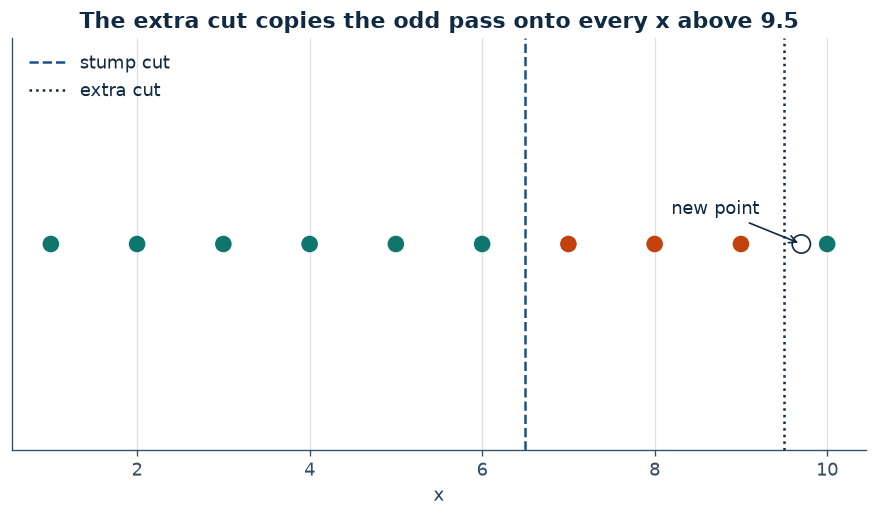

In [2]:
import matplotlib.pyplot as plt

# Quiet page. Pass is green, fail is clay, and the grid stays behind the marks.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# The odd pass at x = 10 pulls a third leaf out past 9.5.
xs = list(range(1, 11))
labels = ["pass"] * 6 + ["fail"] * 3 + ["pass"]
colors = [GREEN if label == "pass" else CLAY for label in labels]
fig, ax = plt.subplots(constrained_layout=True)
ax.scatter(xs, [0] * 10, c=colors, s=80, zorder=3)
ax.axvline(6.5, color=BLUE, linestyle="--", label="stump cut")
ax.axvline(9.5, color=INK, linestyle=":", label="extra cut")
ax.scatter([9.7], [0], facecolors="none", edgecolors=INK, s=120, zorder=4)
ax.annotate(
    "new point",
    (9.7, 0),
    textcoords="offset points",
    xytext=(-78, 18),
    color=INK,
    arrowprops={"arrowstyle": "->", "color": INK},
)
ax.set_yticks([])
ax.set_xlabel("x")
ax.set_title("The extra cut copies the odd pass onto every x above 9.5")
ax.legend(frameon=False)


## A pitfall

Training error $0$ means every training row has a private compatible leaf. It does not mean the questions will be right on a nearby $x$ that was not in the table. A limit on depth, or a minimum number of parts in a leaf, would have refused to cut off a leaf of size $1$.

## What to carry forward

The best first gain on this line is $27/100$, at $x \le 13/2$. One more cut memorizes $x = 10$. The stump misses that training row and gets $x = 9.7$ right.
